# What a wide ΔE double range actually means

`de_range_vs_resistance_time_v1.ipynb` put a drug's ΔE double range against how fast resistance to
it develops and got ρ = 0.64 over 14 drugs — carried by between-class separation, negative inside
the NRTIs, and resting on a y axis pooled from four different selection studies. That is not
evidence that the range has anything to do with how long resistance takes.

So this notebook drops the drug-level axis and asks the question one level down, where the range is
actually measured: **for a double mutation, what is different about a wide ΔE double range?**
Four claims, each tested on all 80 top-ddE DRM pairs across IN, PR and RT.

| # | claim | test |
|---|---|---|
| 1 | ΔE double says *which sequences carry the pair*, wide range or not | AUC of ΔE double separating carriers from non-carriers, per pair |
| 2 | A wide range means **a few background positions dominate**; a narrow one means many positions each do very little | effective number of driver positions, N<sub>eff</sub> = (Σv)²/Σv² over the per-position variance contributions |
| 3 | A wide range means the pair is **favoured in a real fraction of backgrounds**; a narrow-range pair is disfavoured in essentially all of them | fraction of the alignment with ΔE double > 0, against the Gaussian expectation for the same mean and sd |
| 4 | Wide-range pairs are the ones that actually **reach appreciable frequency in patients** | carrier frequency vs range, within protein and partialling out mean ΔE double |

Claims 1 and 2 survive; 3 turns out to be near-mechanical and 4 turns out to be a mean effect rather
than a range effect. The conclusions cell at the bottom says which is which, and the notebook keeps
the failed versions rather than quietly dropping them.

Sign convention is `utilities/functions.calculate_delta_e`: ΔE = E(wild-type) − E(mutant), and the
Potts probability goes as exp(ΔE), so **ΔE double > 0 means the double mutant is favoured** in that
background.

**Read the per-protein numbers, not the pooled ones.** NNRTI pairs are all narrow and IN pairs are
all wide, so a pooled correlation partly measures which protein a pair came from. RT spans 4.3 to
19.8 on its own and carries most of the evidence; IN's 20 pairs span too little range to test
anything and say so below.

## Setup — alignments, J, pairs

In [1]:
import sys
import csv
import importlib
from pathlib import Path

import numpy as np
import pandas as pd

cwd = Path.cwd().resolve()
repo_root = next((c for c in [cwd, *cwd.parents] if (c / "utilities" / "functions.py").exists()), None)
if repo_root is None:
    raise FileNotFoundError("Could not find the repository root containing utilities/functions.py")
sys.path.append(str(repo_root))

import utilities.functions as functions

importlib.reload(functions)

data_root = repo_root / "ms0_5"
out_dir = Path.cwd()


def build_J_matrix(j_file, min_position, max_position):
    """Dense coupling tensor, shape (L, L, 4, 5), indexed [p1, p2, aa_at_p1, aa_at_p2]."""
    J = np.load(j_file).astype(np.float32)
    L = max_position - min_position + 1
    Jm = np.zeros((L, L, 4, 5), dtype=np.float32)
    iu0, iu1 = np.triu_indices(L, 1)
    blocks = J.reshape(-1, 4, 4)
    assert blocks.shape[0] == iu0.size, "J.npy row count does not match the position range"
    Jm[iu0, iu1, :, :4] = blocks
    Jm[iu1, iu0, :, :4] = blocks.transpose(0, 2, 1)
    return Jm


CFG = {
    'IN': dict(seq='IN/data/in.reduce4.seq', redux='IN/data/in.reduce4.redux', offset=1,
               J='IN/data/J.npy', min_pos=1, max_pos=263,
               pair_file='IN/data/top_20_DRM.txt',
               dde_files=['IN_top_1000_dde_summary.csv', 'IN_bottom_1000_dde_summary.csv']),
    'PR': dict(seq='PR/data/pr.exper.reduce4.seq', redux='PR/data/pr.reduce4.redux', offset=0,
               J='PR/data/J_PR.npy', min_pos=1, max_pos=99,
               pair_file='PR/data/top_20_DRM.txt',
               dde_files=['PR_top_1000_dde_summary.csv', 'PR_bottom_1000_dde_summary.csv']),
    'RT': dict(seq='RT/data/rt.reduce4.seq', redux='RT/data/rt.reduce4.redux', offset=0,
               J='RT/data/J_RT.npy', min_pos=39, max_pos=226,
               pair_file='RT/data/top_20_DRM.txt',
               dde_files=['RT_NRTI_top_1000_dde_summary.csv', 'RT_NNRTI_top_1000_dde_summary.csv',
                          'RT_NRTI_bottom_1000_dde_summary.csv',
                          'RT_NNRTI_bottom_1000_dde_summary.csv']),
}

PROTEINS = list(CFG)

_AA_CODE = np.full(256, 4, dtype=np.uint8)
for _i, _c in enumerate("ABCD"):
    _AA_CODE[ord(_c)] = _i


def encode_seqs(seq_list, min_pos, max_pos):
    Ln = max_pos - min_pos + 1
    N = len(seq_list)
    raw = np.frombuffer("".join(seq_list).encode(), dtype=np.uint8)
    assert raw.size == N * Ln, "all sequences must span exactly min_pos..max_pos"
    codes = _AA_CODE[raw.reshape(N, Ln)]
    onehot = np.zeros((N * Ln, 5), dtype=np.float32)
    onehot[np.arange(N * Ln), codes.ravel()] = 1.0
    return codes, onehot.reshape(N, Ln * 5)


for P, cfg in CFG.items():
    cfg['seqs'] = functions.read_seq(str(data_root / cfg['seq']))
    cfg['redux'] = functions.get_redu_dict(str(data_root / cfg['redux']), cfg['offset'])
    cfg['Jm'] = build_J_matrix(str(data_root / cfg['J']), cfg['min_pos'], cfg['max_pos'])
    cfg['L'] = cfg['max_pos'] - cfg['min_pos'] + 1
    cfg['positions'] = np.arange(cfg['min_pos'], cfg['max_pos'] + 1)
    cfg['codes'], cfg['onehot'] = encode_seqs(cfg['seqs'], cfg['min_pos'], cfg['max_pos'])
    cfg['freq'] = np.stack([(cfg['codes'] == a).mean(axis=0) for a in range(5)], axis=1)
    print(f"{P}: {len(cfg['seqs']):>6,} sequences   positions {cfg['min_pos']}-{cfg['max_pos']}"
          f"  (L = {cfg['L']})")

IN:  1,220 sequences   positions 1-263  (L = 263)
PR:  5,710 sequences   positions 1-99  (L = 99)
RT: 19,194 sequences   positions 39-226  (L = 188)


### ΔE double, its per-position variance, and who carries the pair

Three things per pair, all from the same decomposition the leverage notebooks use:

    ΔE double = Σ_q c(q) + [J(p1,p2,wt1,wt2) − J(p1,p2,mt1,mt2)]
    c(q)      = [J(p1,q,wt1,s_q) − J(p1,q,mt1,s_q)] + [J(p2,q,wt2,s_q) − J(p2,q,mt2,s_q)]

`de_double` is the per-sequence value, `var_of_c` is Var(c(q)) at every background position q — what
that one position contributes to the spread — and `carriers` is the boolean of sequences that hold
both mutant residues.

**The carrier flag and ΔE double are computed from disjoint parts of the sequence.** ΔE double sums
over background positions only; positions p1 and p2 are excluded from the sum, and the carrier test
looks only at p1 and p2. Nothing about a sequence's own pair residues enters its ΔE double, so
claim 1 is not circular.

In [2]:
def reduced_idx(P, pair):
    """'M41L-T215Y' -> (p1, p2, wt1, mt1, wt2, mt2) as 0-based position / residue indices."""
    cfg = CFG[P]
    a, b = functions.split_pairs(pair)
    wt1, pos1, mt1 = functions.split_pair(functions.unreduced_to_reduced(cfg['redux'], a))
    wt2, pos2, mt2 = functions.split_pair(functions.unreduced_to_reduced(cfg['redux'], b))
    if '-' in (wt1, mt1, wt2, mt2):
        raise ValueError('residue outside the reduced alphabet')
    if not (cfg['min_pos'] <= pos1 <= cfg['max_pos'] and cfg['min_pos'] <= pos2 <= cfg['max_pos']):
        raise ValueError(f"position outside {cfg['min_pos']}-{cfg['max_pos']}")
    if pos1 == pos2:
        raise ValueError('both mutations at the same position')
    return (pos1 - cfg['min_pos'], pos2 - cfg['min_pos'], "ABCD".index(wt1), "ABCD".index(mt1),
            "ABCD".index(wt2), "ABCD".index(mt2))


def _site_energies(onehot, Jm, p, excluded):
    A = Jm[p].copy()
    A[list(excluded)] = 0.0
    return np.asarray(onehot @ A.transpose(0, 2, 1).reshape(-1, 4), dtype=np.float64)


def de_double(P, pair):
    """dE double per sequence. Background positions only -- p1 and p2 are excluded."""
    cfg = CFG[P]
    p1, p2, wt1, mt1, wt2, mt2 = reduced_idx(P, pair)
    S1 = _site_energies(cfg['onehot'], cfg['Jm'], p1, (p1, p2))
    S2 = _site_energies(cfg['onehot'], cfg['Jm'], p2, (p1, p2))
    J12 = cfg['Jm'][p1, p2, :, :4].astype(np.float64)
    M = S1[:, :, None] + S2[:, None, :] + J12[None, :, :]
    return M[:, wt1, wt2] - M[:, mt1, mt2]


def var_of_c(P, pair):
    """Var(c(q)) at every background position, straight off the residue frequencies."""
    cfg = CFG[P]
    p1, p2, wt1, mt1, wt2, mt2 = reduced_idx(P, pair)
    J = cfg['Jm']
    CV = ((J[p1, :, wt1, :] - J[p1, :, mt1, :])
          + (J[p2, :, wt2, :] - J[p2, :, mt2, :])).astype(np.float64)
    CV[[p1, p2]] = 0.0
    F = cfg['freq']
    mu = (F * CV).sum(axis=1)
    return np.maximum((F * CV ** 2).sum(axis=1) - mu ** 2, 0.0)


def carriers_of(P, pair):
    """Sequences holding BOTH mutant residues, read only at p1 and p2."""
    cfg = CFG[P]
    p1, p2, wt1, mt1, wt2, mt2 = reduced_idx(P, pair)
    return (cfg['codes'][:, p1] == mt1) & (cfg['codes'][:, p2] == mt2)


# the identity that licenses the variance decomposition, checked rather than assumed
_p = 'M41L-T215Y'
_v = var_of_c('RT', _p)
print(f"RT {_p}: Var(dE double) = {de_double('RT', _p).var():.3f}   "
      f"sum of per-position Var(c(q)) = {_v.sum():.3f}")
print("  (the two differ by the covariance between positions -- the alignment is not a product "
      "of independent sites, so N_eff below is a descriptive summary of the per-position terms, "
      "not an exact variance partition)")

RT M41L-T215Y: Var(dE double) = 32.229   sum of per-position Var(c(q)) = 8.752
  (the two differ by the covariance between positions -- the alignment is not a product of independent sites, so N_eff below is a descriptive summary of the per-position terms, not an exact variance partition)


## The per-pair table

One row per pair. `AUC` is the probability that a randomly chosen carrier has a higher ΔE double
than a randomly chosen non-carrier — 0.5 is no separation, 1.0 is perfect. `N_eff` is
(Σv)²/Σv² over the per-position variance contributions: 1 if a single position carried everything,
L if every position contributed equally. `frac favoured` is the share of the alignment with
ΔE double > 0, and `gaussian frac` is what that share would be for a normal distribution with the
same mean and sd — the difference is the part that is *not* just a consequence of a wider spread.

In [3]:
def load_dde(P):
    out = {}
    for fn in CFG[P]['dde_files']:
        for r in csv.DictReader(open(data_root / fn, newline='')):
            out.setdefault(r['double_mutation_pair'].strip(), float(r['dde']))
    return out


def auc_of(score, label):
    """P(score[carrier] > score[non-carrier]), Mann-Whitney form, ties counted as half."""
    n1 = int(label.sum())
    n0 = int(len(label) - n1)
    if n1 == 0 or n0 == 0:
        return np.nan
    r = pd.Series(score).rank().to_numpy()
    return (r[label].sum() - n1 * (n1 + 1) / 2) / (n1 * n0)


try:
    from scipy.stats import norm, spearmanr
    HAVE_SCIPY = True
except Exception:
    HAVE_SCIPY = False

N_DECILE = 10
ROWS, DECILES, DE_CACHE, VAR_CACHE, CARR_CACHE = [], [], {}, {}, {}

for P in PROTEINS:
    dde = load_dde(P)
    seen = set()
    for line in (data_root / CFG[P]['pair_file']).read_text().splitlines():
        line = line.strip()
        if not line:
            continue
        pair = '-'.join(tok.strip() for tok in line.split('-'))
        if pair in seen:
            continue
        try:
            p1, p2, *_ = reduced_idx(P, pair)
            de = de_double(P, pair)
        except Exception:
            continue
        seen.add(pair)
        v = var_of_c(P, pair)
        carr = carriers_of(P, pair)
        DE_CACHE[(P, pair)], VAR_CACHE[(P, pair)], CARR_CACHE[(P, pair)] = de, v, carr

        lo, hi = np.percentile(de, [5, 95])
        mu, sd = de.mean(), de.std()
        order = np.argsort(de)
        bins = np.array_split(order, N_DECILE)
        freq_by_bin = np.array([carr[b].mean() for b in bins])
        overall = carr.mean()
        for k, (b, f) in enumerate(zip(bins, freq_by_bin)):
            DECILES.append({'protein': P, 'pair': pair, 'decile': k + 1,
                            'mean dE in decile': de[b].mean(), 'carrier freq': f,
                            'fold vs pair mean': f / overall if overall > 0 else np.nan})

        top = np.argsort(-v)[:3]
        ROWS.append({
            'protein': P, 'pair': pair,
            'range': hi - lo, 'mean dE double': mu, 'sd': sd,
            'carriers': int(carr.sum()), 'carrier freq': overall,
            'AUC': auc_of(de, carr),
            'N_eff': (v.sum() ** 2) / (v ** 2).sum(),
            'top position share': v[top].sum() / v.sum(),
            'frac favoured': float((de > 0).mean()),
            'gaussian frac': float(1 - norm.cdf(0, mu, sd)) if HAVE_SCIPY else np.nan,
            'top decile fold': freq_by_bin[-1] / overall if overall > 0 else np.nan,
            'bottom decile fold': freq_by_bin[0] / overall if overall > 0 else np.nan,
            'driver positions': ', '.join(str(CFG[P]['positions'][q]) for q in top),
            'ddE': dde.get(pair, np.nan),
        })

PAIRS = pd.DataFrame(ROWS)
DEC = pd.DataFrame(DECILES)
MIN_CARRIERS = 10
OK = PAIRS['carriers'] >= MIN_CARRIERS

pd.set_option('display.max_columns', None, 'display.width', 230, 'display.max_rows', 100)
print(f"{len(PAIRS)} pairs   {int(OK.sum())} with at least {MIN_CARRIERS} carriers "
      f"(the rest are too rare to rank carriers against non-carriers)")
PAIRS.sort_values(['protein', 'range'], ascending=[True, False]).round(3)

80 pairs   71 with at least 10 carriers (the rest are too rare to rank carriers against non-carriers)


,protein,pair,range,mean dE double,sd,carriers,carrier freq,AUC,N_eff,top position share,frac favoured,gaussian frac,top decile fold,bottom decile fold,driver positions,ddE
17,IN,E138A-Q148H,16.743,-8.039,5.204,15,0.012,0.975,2.279,0.783,0.125,0.061,9.333,0.000,"140, 155, 124",2.13
13,IN,E138K-Q148H,15.800,-7.475,5.029,11,0.009,0.998,2.213,0.801,0.148,0.069,10.000,0.000,"140, 155, 143",2.36
7,IN,E138K-Q148R,13.570,-7.032,4.316,22,0.018,0.968,6.484,0.529,0.058,0.052,8.636,0.000,"140, 155, 156",3.53
5,IN,E138K-Q148K,12.485,-9.187,3.885,4,0.003,0.997,5.373,0.543,0.014,0.009,10.000,0.000,"140, 155, 119",4.90
11,IN,S147G-Q148R,11.917,-9.523,3.958,11,0.009,1.000,14.919,0.380,0.021,0.008,10.000,0.000,"140, 138, 155",2.65
2,IN,G140A-Q148K,11.879,-11.140,3.764,4,0.003,1.000,20.512,0.301,0.007,0.002,10.000,0.000,"155, 138, 124",5.61
9,IN,T97A-Y143R,11.771,-6.839,3.605,39,0.032,0.948,12.713,0.417,0.048,0.029,8.462,0.000,"155, 148, 119",2.84
4,IN,G140A-Q148R,11.608,-8.390,3.712,10,0.008,0.982,17.073,0.316,0.020,0.012,9.000,0.000,"155, 39, 138",4.91
3,IN,G140S-Q148R,11.487,-6.153,3.517,19,0.016,0.952,8.493,0.451,0.033,0.040,7.895,0.000,"155, 143, 151",5.20
19,IN,V54I-G140C,11.342,-11.487,3.574,4,0.003,1.000,19.076,0.326,0.005,0.001,10.000,0.000,"148, 124, 155",2.03


## Claim 1 — the background says who carries the pair, at every range

AUC per pair: the probability that a carrier's background scores higher on ΔE double than a
non-carrier's. Both panels are the same 80 pairs.

If this were near 0.5 the rest of the notebook would be pointless — ΔE double would not be tracking
anything real about which sequences hold the mutation. It is not near 0.5 for any pair, and the
AUC does **not** rise with range: background dependence is a property of every one of these pairs,
and the range is about *how much* the background moves ΔE double, not *whether* it does.

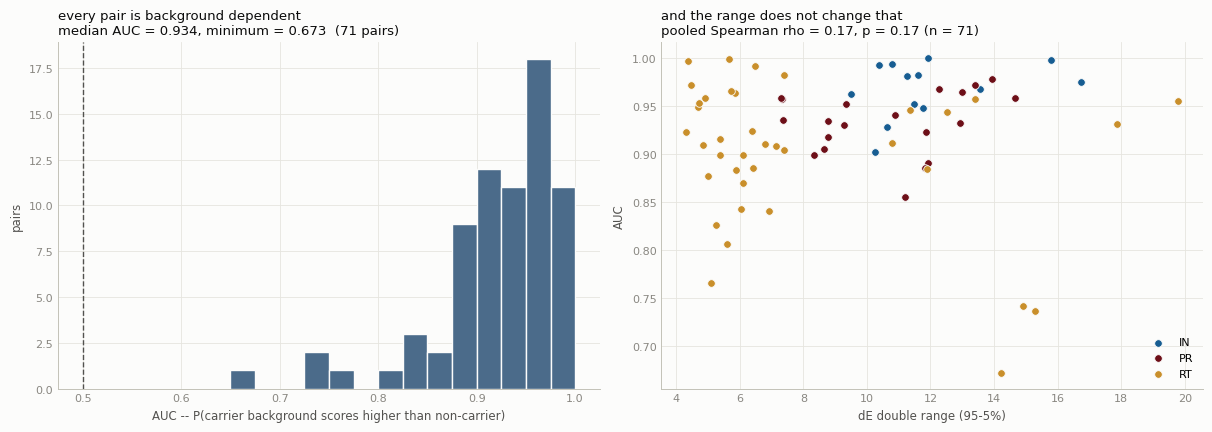

In [4]:
import matplotlib.pyplot as plt

SURFACE, INK, INK2, MUTED, GRID, BASE = '#fcfcfb', '#0b0b0b', '#52514e', '#898781', '#e6e5df', '#c3c2b7'
PROT_COLOR = {'IN': '#175d92', 'PR': '#6d0f18', 'RT': '#c98f2b'}

plt.rcParams.update({'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE,
                     'savefig.facecolor': SURFACE, 'font.size': 9, 'legend.frameon': False,
                     'axes.edgecolor': BASE, 'axes.linewidth': 0.7})


def bare(ax, grid='both'):
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)
    for s in ('left', 'bottom'):
        ax.spines[s].set_color(BASE)
    ax.tick_params(length=0, labelsize=8, colors=MUTED)
    ax.grid(axis=grid, color=GRID, linewidth=0.6)
    ax.set_axisbelow(True)
    return ax


def rho(x, y):
    """Spearman rho, p and n over the rows where both are finite."""
    x, y = np.asarray(x, float), np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y)
    if m.sum() < 4:
        return np.nan, np.nan, int(m.sum())
    if HAVE_SCIPY:
        r = spearmanr(x[m], y[m])
        return float(r.statistic), float(r.pvalue), int(m.sum())
    rx, ry = pd.Series(x[m]).rank().to_numpy(), pd.Series(y[m]).rank().to_numpy()
    return float(np.corrcoef(rx, ry)[0, 1]), np.nan, int(m.sum())


def partial_rho(x, y, z):
    """Spearman of x and y with z partialled out -- correlation of the rank residuals."""
    x, y, z = (np.asarray(v, float) for v in (x, y, z))
    m = np.isfinite(x) & np.isfinite(y) & np.isfinite(z)
    if m.sum() < 5:
        return np.nan, int(m.sum())
    rk = [pd.Series(v[m]).rank().to_numpy() for v in (x, y, z)]
    rk = [(v - v.mean()) / v.std() for v in rk]
    rxy, rxz, ryz = (np.corrcoef(rk[0], rk[1])[0, 1], np.corrcoef(rk[0], rk[2])[0, 1],
                     np.corrcoef(rk[1], rk[2])[0, 1])
    den = np.sqrt((1 - rxz ** 2) * (1 - ryz ** 2))
    return (float((rxy - rxz * ryz) / den) if den > 0 else np.nan), int(m.sum())


sub = PAIRS[OK]
fig, axes = plt.subplots(1, 2, figsize=(12.2, 4.4))

ax = bare(axes[0])
ax.hist(sub['AUC'], bins=np.arange(0.5, 1.02, 0.025), color='#4b6b8a', edgecolor=SURFACE)
ax.axvline(0.5, color=INK2, lw=1, ls='--')
ax.set_xlabel('AUC -- P(carrier background scores higher than non-carrier)', fontsize=8.5, color=INK2)
ax.set_ylabel('pairs', fontsize=8.5, color=INK2)
ax.set_title(f"every pair is background dependent\nmedian AUC = {sub['AUC'].median():.3f}, "
             f"minimum = {sub['AUC'].min():.3f}  ({len(sub)} pairs)",
             fontsize=9.5, color=INK, loc='left')

ax = bare(axes[1])
for P, g in sub.groupby('protein'):
    ax.scatter(g['range'], g['AUC'], s=30, color=PROT_COLOR[P], label=P,
               edgecolor=SURFACE, linewidth=.6)
r, p, n = rho(sub['range'], sub['AUC'])
ax.set_xlabel('dE double range (95-5%)', fontsize=8.5, color=INK2)
ax.set_ylabel('AUC', fontsize=8.5, color=INK2)
ax.set_title(f"and the range does not change that\npooled Spearman rho = {r:.2f}, p = {p:.2f} "
             f"(n = {n})", fontsize=9.5, color=INK, loc='left')
ax.legend(fontsize=8, loc='lower right')

fig.tight_layout()
fig.savefig(out_dir / 'de_range_meaning_auc.png', dpi=220, bbox_inches='tight')
plt.show()

### The same gradient, whatever the range

Every pair's alignment is split into ten deciles of ΔE double and the carrier frequency is measured
in each, divided by the pair's own overall frequency so pairs of very different rarity can be laid
on one axis. A flat line at 1 would mean the background does not matter.

Pairs are split into range tertiles, and **the three curves lie on top of each other**: the top
decile of background holds about 7× the pair's average carrier frequency whether the pair's range
is 4 or 20, and the bottom four deciles hold essentially no carriers in every tertile. This is a
negative result for the obvious reading of "wide range", and it is the useful one — a wide range
does **not** mean the background gates the pair more strongly in relative terms. The ordering of
backgrounds and the enrichment it produces are the same; what differs is the energy scale that
ordering is spread over.

The right panel is the same point pair by pair, and it needs the correction below: raw
top-decile enrichment is flat pooled but *falls* with range inside RT, purely because RT's widest
pairs are also its commonest and enrichment is capped at 1/frequency.

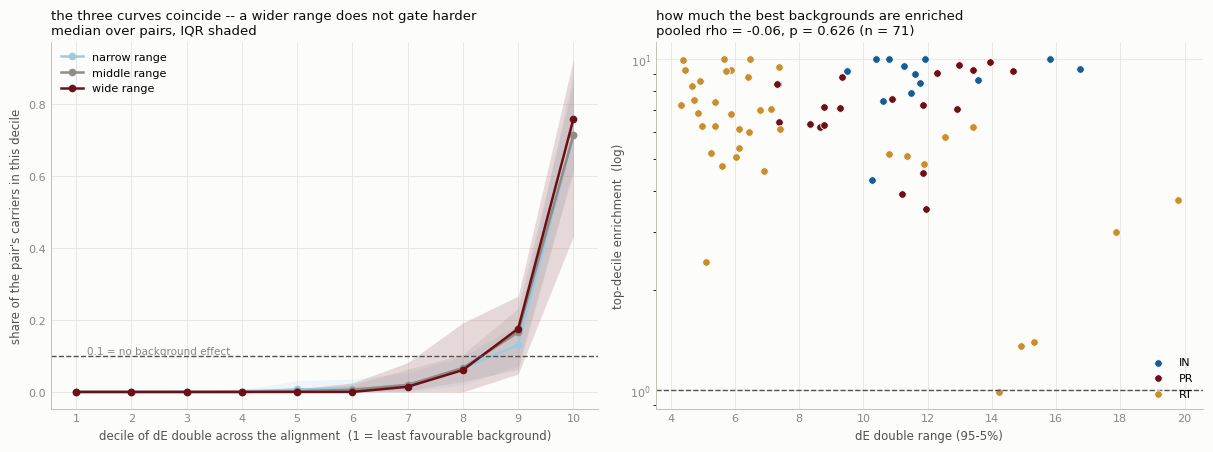

median share of a pair's carriers per decile, by range tertile:
decile    1    2    3    4      5      6      7      8      9      10
tertile                                                              
narrow   0.0  0.0  0.0  0.0  0.007  0.008  0.013  0.065  0.130  0.714
middle   0.0  0.0  0.0  0.0  0.002  0.006  0.020  0.067  0.166  0.713
wide     0.0  0.0  0.0  0.0  0.000  0.000  0.014  0.061  0.176  0.758


In [5]:
TERT = PAIRS.loc[OK, ['protein', 'pair', 'range']].copy()
TERT['tertile'] = pd.qcut(TERT['range'], 3, labels=['narrow', 'middle', 'wide'])
DECT = DEC.merge(TERT[['protein', 'pair', 'tertile']], on=['protein', 'pair'], how='inner')

fig, axes = plt.subplots(1, 2, figsize=(12.2, 4.6))
TCOL = {'narrow': '#9ecae1', 'middle': '#8f8d86', 'wide': '#6d0f18'}

# Share of a pair's carriers falling in each decile -- equal-size bins, so this is just the
# fold enrichment over ten. Linear axis: the log version puts the empty low deciles on the
# floor and hides the only thing worth seeing, which is that the three curves coincide.
DECT['carrier share'] = DECT['fold vs pair mean'] / N_DECILE

ax = bare(axes[0])
for t in ['narrow', 'middle', 'wide']:
    g = DECT[DECT['tertile'] == t].groupby('decile')['carrier share']
    med, q1, q3 = g.median(), g.quantile(.25), g.quantile(.75)
    ax.fill_between(med.index, q1, q3, color=TCOL[t], alpha=.15, linewidth=0)
    ax.plot(med.index, med, color=TCOL[t], lw=1.8, marker='o', ms=4.5, label=f'{t} range')
ax.axhline(0.1, color=INK2, lw=1, ls='--')
ax.annotate('0.1 = no background effect', xy=(1.2, 0.105), fontsize=7.5, color=MUTED)
ax.set_xticks(range(1, 11))
ax.set_xlabel('decile of dE double across the alignment  (1 = least favourable background)',
              fontsize=8.5, color=INK2)
ax.set_ylabel("share of the pair's carriers in this decile", fontsize=8.5, color=INK2)
ax.set_title('the three curves coincide -- a wider range does not gate harder\n'
             'median over pairs, IQR shaded', fontsize=9.5, color=INK, loc='left')
ax.legend(fontsize=8, loc='upper left')

ax = bare(axes[1])
for P, g in sub.groupby('protein'):
    ax.scatter(g['range'], g['top decile fold'], s=30, color=PROT_COLOR[P], label=P,
               edgecolor=SURFACE, linewidth=.6)
r, p, n = rho(sub['range'], sub['top decile fold'])
ax.set_yscale('log')
ax.axhline(1, color=INK2, lw=1, ls='--')
ax.set_xlabel('dE double range (95-5%)', fontsize=8.5, color=INK2)
ax.set_ylabel('top-decile enrichment  (log)', fontsize=8.5, color=INK2)
ax.set_title(f'how much the best backgrounds are enriched\npooled rho = {r:.2f}, p = {p:.3f} '
             f'(n = {n})', fontsize=9.5, color=INK, loc='left')
ax.legend(fontsize=8, loc='lower right')

fig.tight_layout()
fig.savefig(out_dir / 'de_range_meaning_gradient.png', dpi=220, bbox_inches='tight')
plt.show()

print("median share of a pair's carriers per decile, by range tertile:")
print(DECT.groupby(['tertile', 'decile'], observed=True)['carrier share'].median()
      .unstack().round(3).to_string())

#### The ceiling on that enrichment

Top-decile enrichment cannot exceed 1 / (the pair's own frequency), and it is capped at 10 by the
decile binning. M41L-T215Y is carried by 32% of the alignment, so its enrichment cannot pass 3.1
however perfectly the background sorts it — and the widest pairs are exactly the common ones. So
the raw enrichment must be divided by what each pair could attain before it says anything.

In [6]:
SAT = PAIRS[OK].copy()
SAT['max attainable fold'] = np.minimum(N_DECILE, 1 / SAT['carrier freq'])
SAT['saturation'] = SAT['top decile fold'] / SAT['max attainable fold']

print("top-decile enrichment vs range, raw and as a share of what the pair could attain")
for P, g in list(SAT.groupby('protein')) + [('all', SAT)]:
    raw = rho(g['range'], g['top decile fold'])
    sat = rho(g['range'], g['saturation'])
    print(f"   {P:<4} raw rho = {raw[0]:6.3f} (p = {raw[1]:.3f})   "
          f"saturation rho = {sat[0]:6.3f} (p = {sat[1]:.3f})   "
          f"median saturation = {g['saturation'].median():.2f}  (n = {raw[2]})")
print("\n   RT's raw -0.56 is the ceiling, not a real loss of gating: its widest pairs are its")
print("   commonest ones. Once each pair is scored against its own maximum the relation is flat")
print("   everywhere, which is what the coinciding decile curves already said.\n")

display(SAT.nlargest(6, 'range')[['protein', 'pair', 'range', 'carrier freq', 'top decile fold',
                                  'max attainable fold', 'saturation']].round(3))

top-decile enrichment vs range, raw and as a share of what the pair could attain
   IN   raw rho =  0.314 (p = 0.296)   saturation rho =  0.303 (p = 0.314)   median saturation = 0.92  (n = 13)
   PR   raw rho =  0.409 (p = 0.073)   saturation rho =  0.417 (p = 0.068)   median saturation = 0.72  (n = 20)
   RT   raw rho = -0.559 (p = 0.000)   saturation rho = -0.240 (p = 0.147)   median saturation = 0.68  (n = 38)
   all  raw rho = -0.059 (p = 0.626)   saturation rho =  0.128 (p = 0.288)   median saturation = 0.75  (n = 71)

   RT's raw -0.56 is the ceiling, not a real loss of gating: its widest pairs are its
   commonest ones. Once each pair is scored against its own maximum the relation is flat
   everywhere, which is what the coinciding decile curves already said.



,protein,pair,range,carrier freq,top decile fold,max attainable fold,saturation
46,RT,L210W-T215Y,19.798,0.249,3.737,4.020,0.930
41,RT,M41L-T215Y,17.862,0.319,2.997,3.139,0.955
17,IN,E138A-Q148H,16.743,0.012,9.333,10.000,0.933
13,IN,E138K-Q148H,15.800,0.009,10.000,10.000,1.000
52,RT,L210W-T215S,15.296,0.010,1.399,10.000,0.140
50,RT,M41L-T215F,14.916,0.057,1.357,10.000,0.136


## Claims 2–4 — what does separate a wide pair from a narrow one

Three panels, each against the range, coloured by protein, with the per-protein ρ printed because
the pooled one partly measures which protein a pair came from.

**N_eff — this is the real one.** A wide range is a *concentrated* range: one or two background
positions carry the spread. A narrow-range pair has its (small) spread smeared over ten to twenty
positions that each nudge it slightly. Within RT, where the range actually varies, ρ = −0.58
(p = 0.0002); PR gives −0.44 (p = 0.05). This is the mechanistic difference, and it says what to do
next — name the positions, which the next section does.

**frac favoured** — a wide-range pair is favoured over wild-type in a real slice of the alignment,
a narrow one in essentially none of it. The correlation is the strongest in the notebook (RT
ρ = 0.70) and also the least informative: the cell below shows it is close to what a wider spread at
the same mean would give under a Gaussian (ρ ≈ 0.97 between observed and Gaussian expectation). It
restates the range rather than adding to it. The one part that is not mechanical is the ratio —
the observed favourable share runs about 1.65× the Gaussian one, so that end of the distribution is
fatter than a normal tail.

**carrier frequency** — wide pairs are the common ones (RT ρ = 0.63). Partialling out the mean
ΔE double asks whether that is anything more than "wide pairs are also energetically better on
average", and **inside RT it mostly is not**: the partial ρ falls to 0.17. Pooled across proteins it
holds up better (0.40 → 0.36), but the pooled number carries the protein confound. Treat this as
mean-driven, not range-driven.

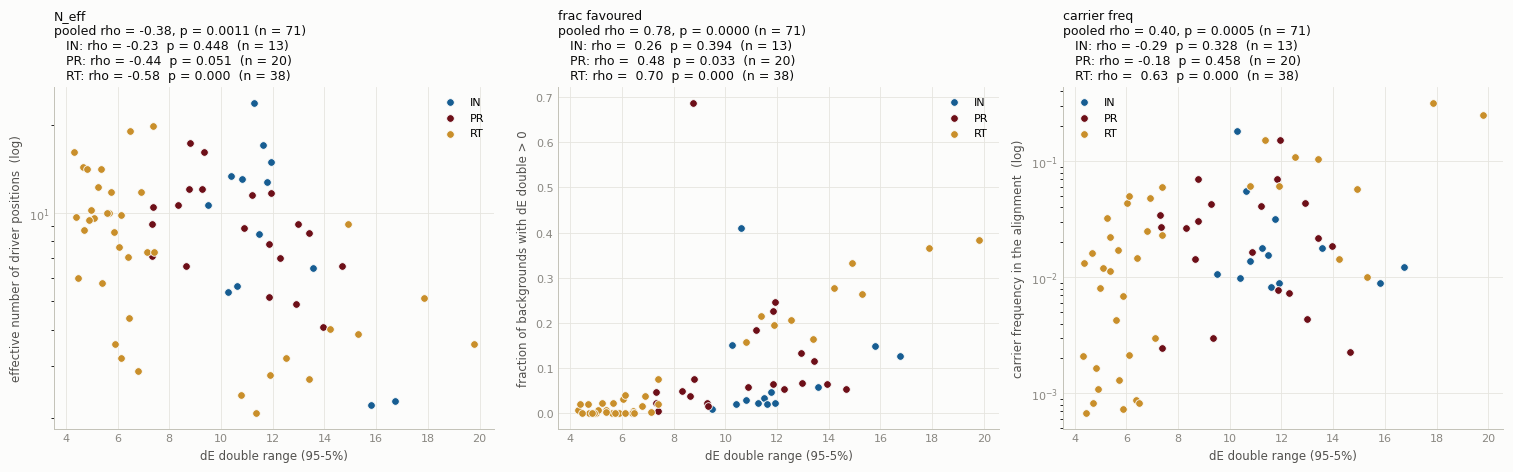

In [7]:
PANELS = [('N_eff', 'effective number of driver positions  (log)', True),
          ('frac favoured', 'fraction of backgrounds with dE double > 0', False),
          ('carrier freq', "carrier frequency in the alignment  (log)", True)]

fig, axes = plt.subplots(1, 3, figsize=(15.2, 4.8))
for ax, (col, ylab, logy) in zip(axes, PANELS):
    bare(ax)
    for P, g in sub.groupby('protein'):
        ax.scatter(g['range'], g[col], s=30, color=PROT_COLOR[P], label=P,
                   edgecolor=SURFACE, linewidth=.6)
    if logy:
        ax.set_yscale('log')
    r, p, n = rho(sub['range'], sub[col])
    per = '\n'.join(f"   {P}: rho = {rho(g['range'], g[col])[0]:5.2f}  "
                    f"p = {rho(g['range'], g[col])[1]:.3f}  (n = {len(g)})"
                    for P, g in sub.groupby('protein'))
    ax.set_xlabel('dE double range (95-5%)', fontsize=8.5, color=INK2)
    ax.set_ylabel(ylab, fontsize=8.5, color=INK2)
    ax.set_title(f"{col}\npooled rho = {r:.2f}, p = {p:.4f} (n = {n})\n{per}",
                 fontsize=9, color=INK, loc='left')
    ax.legend(fontsize=8, loc='best')

fig.tight_layout()
fig.savefig(out_dir / 'de_range_meaning_three_panels.png', dpi=220, bbox_inches='tight')
plt.show()

In [8]:
# --- the checks the three panels lean on -------------------------------------------------
print("frac favoured vs the Gaussian expectation for the same mean and sd")
r, p, n = rho(sub['frac favoured'], sub['gaussian frac'])
ratio = (sub['frac favoured'] / sub['gaussian frac'].clip(lower=1e-6))
print(f"   rho = {r:.3f} (n = {n})   median observed / gaussian = {ratio.median():.2f}")
print("   -- so the correlation with range is largely mechanical: a wider spread at the same "
      "mean\n      puts more mass above zero. The excess over the Gaussian is the part that is "
      "not.\n")

print("carrier frequency vs range, with mean dE double partialled out")
for P, g in list(sub.groupby('protein')) + [('all', sub)]:
    raw = rho(g['range'], g['carrier freq'])
    par = partial_rho(g['range'], g['carrier freq'], g['mean dE double'])
    print(f"   {P:<4} raw rho = {raw[0]:6.3f} (p = {raw[1]:.4f}, n = {raw[2]})   "
          f"partial rho | mean dE = {par[0]:6.3f} (n = {par[1]})")

print("\nrange spanned by each protein's pairs -- why IN cannot test any of this")
print(sub.groupby('protein')['range'].agg(['count', 'min', 'median', 'max']).round(2).to_string())

frac favoured vs the Gaussian expectation for the same mean and sd
   rho = 0.973 (n = 71)   median observed / gaussian = 1.65
   -- so the correlation with range is largely mechanical: a wider spread at the same mean
      puts more mass above zero. The excess over the Gaussian is the part that is not.

carrier frequency vs range, with mean dE double partialled out
   IN   raw rho = -0.295 (p = 0.3282, n = 13)   partial rho | mean dE = -0.514 (n = 13)
   PR   raw rho = -0.176 (p = 0.4581, n = 20)   partial rho | mean dE =  0.312 (n = 20)
   RT   raw rho =  0.633 (p = 0.0000, n = 38)   partial rho | mean dE =  0.170 (n = 38)
   all  raw rho =  0.400 (p = 0.0005, n = 71)   partial rho | mean dE =  0.361 (n = 71)

range spanned by each protein's pairs -- why IN cannot test any of this
         count   min  median    max
protein                            
IN          13  9.50   11.49  16.74
PR          20  7.31   11.04  14.67
RT          38  4.31    6.12  19.80


## Which positions are the drivers

If a wide range means a few positions carry it, those positions have names. For the ten widest
pairs: the three background positions with the largest Var(c(q)), what share of the total they
carry, and whether each is itself an IAS-USA resistance position.

The widest pairs are dominated by a single companion DRM — L210W-T215Y by position **41** (51% of
the spread), M41L-T215Y by **210** (41%), both IN E138x-Q148H pairs by **140** (65%), the PR pairs
by **82** and **10**. These are the TAM and INSTI partner positions, so the widest pairs are the
ones whose cost is set by whether the sequence already carries the rest of the resistance cluster.

The second calculation below checks whether *leaning on resistance positions* is what makes a range
wide, and it is not: the share of the spread sitting on DRM positions is high for **every** pair
(median 0.80 in RT against 0.16 of positions, 0.85 in PR against 0.30), and its correlation with
range is null pooled (ρ = −0.09) and inside RT (−0.16). Narrow pairs also live off resistance
positions; they just get less out of them. Only PR shows a within-protein relation (ρ = 0.57).

In [9]:
DRUGS = {
    'IN': {'bictegravir': [118, 138, 140, 148, 153, 263],
           'cabotegravir': [66, 74, 97, 118, 138, 140, 148, 153, 155, 263],
           'dolutegravir': [118, 138, 140, 147, 148, 153, 155, 263],
           'elvitegravir': [66, 92, 97, 118, 121, 138, 140, 147, 148, 155, 263],
           'raltegravir': [74, 92, 97, 118, 121, 138, 140, 143, 148, 155, 263]},
    'PR': {'atazanavir': [10, 20, 24, 32, 33, 46, 48, 50, 53, 54, 73, 82, 84, 85, 88, 90],
           'darunavir': [11, 32, 33, 47, 50, 54, 74, 76, 84, 89],
           'fosamprenavir': [10, 32, 46, 47, 50, 54, 73, 76, 82, 84, 90],
           'indinavir': [10, 20, 24, 32, 36, 46, 54, 71, 73, 76, 77, 82, 84, 90],
           'lopinavir': [10, 20, 24, 32, 33, 46, 47, 50, 53, 54, 71, 73, 76, 82, 84, 90],
           'nelfinavir': [10, 30, 36, 46, 71, 77, 82, 84, 88, 90],
           'saquinavir': [10, 24, 48, 54, 62, 71, 73, 77, 82, 84, 90],
           'tipranavir': [10, 33, 36, 43, 46, 47, 54, 58, 69, 74, 82, 83, 84, 89]},
    'RT': {'zidovudine': [41, 67, 70, 210, 215, 219], 'stavudine': [41, 65, 67, 70, 210, 215, 219],
           'didanosine': [65, 74], 'abacavir': [65, 74, 115, 184],
           'emtricitabine/lamivudine': [65, 184], 'tenofovir': [65, 70],
           'TAMs': [41, 70, 210, 215, 219],
           '69 insertion complex': [41, 62, 69, 70, 210, 215, 219],
           '151 complex': [62, 75, 77, 116, 151],
           'doravirine': [98, 106, 188, 190, 225, 227, 230, 234, 318],
           'efavirenz': [100, 101, 103, 106, 108, 181, 188, 190, 225, 230],
           'etravirine': [90, 98, 100, 101, 106, 138, 179, 181, 190, 230],
           'nevirapine': [100, 101, 103, 106, 108, 181, 188, 190, 230],
           'rilpivirine': [100, 101, 138, 179, 181, 188, 221, 227, 230]},
}
DRM_POS = {P: {q for lst in DRUGS[P].values() for q in lst} for P in PROTEINS}


def drivers(P, pair, k=3):
    v = VAR_CACHE[(P, pair)]
    top = np.argsort(-v)[:k]
    return [(int(CFG[P]['positions'][q]), v[q] / v.sum(),
             int(CFG[P]['positions'][q]) in DRM_POS[P]) for q in top]


rows = []
for _, r in PAIRS[OK].sort_values('range', ascending=False).head(10).iterrows():
    d = drivers(r['protein'], r['pair'])
    rows.append({'protein': r['protein'], 'pair': r['pair'], 'range': r['range'],
                 'N_eff': r['N_eff'],
                 'top 3 positions': ', '.join(f"{q}{'*' if drm else ''} ({s:.0%})"
                                              for q, s, drm in d),
                 'share of spread': sum(s for _, s, _ in d),
                 'DRM among top 3': sum(drm for _, _, drm in d)})
WIDEST = pd.DataFrame(rows)
print("* = the position is itself an IAS-USA resistance position\n")
display(WIDEST.round(3))

# the same question over all pairs: do wide pairs lean on resistance positions?
share_drm = []
for _, r in PAIRS[OK].iterrows():
    P, pair = r['protein'], r['pair']
    v = VAR_CACHE[(P, pair)]
    m = np.array([int(q) in DRM_POS[P] for q in CFG[P]['positions']])
    share_drm.append({'protein': P, 'pair': pair, 'range': r['range'],
                      'share of spread on DRM positions': v[m].sum() / v.sum(),
                      'DRM share of positions': m.mean()})
DRM_SHARE = pd.DataFrame(share_drm)
r, p, n = rho(DRM_SHARE['range'], DRM_SHARE['share of spread on DRM positions'])
print(f"\nshare of the spread carried by resistance positions, vs range: "
      f"rho = {r:.2f}, p = {p:.4f} (n = {n})")
for P, g in DRM_SHARE.groupby('protein'):
    rr = rho(g['range'], g['share of spread on DRM positions'])
    print(f"   {P}: rho = {rr[0]:6.3f} (p = {rr[1]:.3f}, n = {rr[2]})   "
          f"median share {g['share of spread on DRM positions'].median():.2f} "
          f"vs {g['DRM share of positions'].median():.2f} of positions")

* = the position is itself an IAS-USA resistance position



,protein,pair,range,N_eff,top 3 positions,share of spread,DRM among top 3
0,RT,L210W-T215Y,19.798,3.583,"41* (51%), 214 (9%), 118 (5%)",0.651,1
1,RT,M41L-T215Y,17.862,5.146,"210* (41%), 44 (8%), 214 (8%)",0.568,1
2,IN,E138A-Q148H,16.743,2.279,"140* (65%), 155* (10%), 124 (3%)",0.783,2
3,IN,E138K-Q148H,15.800,2.213,"140* (66%), 155* (11%), 143* (3%)",0.801,3
4,RT,L210W-T215S,15.296,3.873,"41* (49%), 118 (6%), 67* (6%)",0.607,2
5,RT,M41L-T215F,14.916,9.189,"210* (27%), 67* (11%), 43 (9%)",0.472,2
6,PR,I54A-A71I,14.668,6.605,"82* (30%), 10* (21%), 48* (7%)",0.582,3
7,RT,M41L-T215S,14.212,4.034,"210* (48%), 44 (7%), 43 (7%)",0.618,1
8,PR,G48V-I54A,13.951,4.072,"82* (43%), 10* (23%), 73* (5%)",0.707,3
9,IN,E138K-Q148R,13.570,6.484,"140* (36%), 155* (14%), 156 (4%)",0.529,2



share of the spread carried by resistance positions, vs range: rho = -0.09, p = 0.4480 (n = 71)
   IN: rho =  0.500 (p = 0.082, n = 13)   median share 0.48 vs 0.05 of positions
   PR: rho =  0.570 (p = 0.009, n = 20)   median share 0.85 vs 0.30 of positions
   RT: rho = -0.164 (p = 0.325, n = 38)   median share 0.80 vs 0.16 of positions


## Back to drugs

The pair-level result rolled up the same way the previous notebook did: a drug's pairs are the ones
whose positions it lists. What a wide range buys at the drug level is not a claim about weeks to
resistance — it is a claim about **where** that drug's resistance pairs are reachable.

In [10]:
def pair_index(P, pair):
    return PAIRS.index[(PAIRS['protein'] == P) & (PAIRS['pair'] == pair)][0]


SELF = {P: {} for P in PROTEINS}
for (P, pair) in DE_CACHE:
    p1, p2, *_ = reduced_idx(P, pair)
    SELF[P][pair] = (p1, p2)

rows, long = [], []
for P in PROTEINS:
    for d, plist in DRUGS[P].items():
        mask = np.zeros(CFG[P]['L'], dtype=bool)
        for q in plist:
            if CFG[P]['min_pos'] <= q <= CFG[P]['max_pos']:
                mask[q - CFG[P]['min_pos']] = True
        idx = [pair_index(P, pair) for pair, (p1, p2) in SELF[P].items() if mask[p1] or mask[p2]]
        g = PAIRS.loc[idx]
        g = g[g['carriers'] >= MIN_CARRIERS]
        if len(g) < 3:
            continue
        for _, rr in g.iterrows():
            long.append({'protein': P, 'drug': d, 'pair': rr['pair'], 'range': rr['range'],
                         'carriers': rr['carriers'], 'N_eff': rr['N_eff']})
        rows.append({'protein': P, 'drug': d, 'pairs': len(g),
                     'median range': g['range'].median(),
                     'median N_eff': g['N_eff'].median(),
                     'median frac favoured': g['frac favoured'].median(),
                     'median carrier freq': g['carrier freq'].median(),
                     'median top-decile fold': g['top decile fold'].median()})
DRUG = pd.DataFrame(rows).sort_values('median range', ascending=False)
DRUG_PAIRS = pd.DataFrame(long)      # one row per (drug, pair) -- what the box plot below draws
display(DRUG.round(3))

for col in ['median N_eff', 'median frac favoured', 'median carrier freq']:
    r, p, n = rho(DRUG['median range'], DRUG[col])
    print(f"drug-level: median range vs {col:<22s} rho = {r:6.3f}  p = {p:.4f}  (n = {n})")

PAIRS.to_csv(out_dir / 'de_range_meaning_per_pair.csv', index=False)
DEC.to_csv(out_dir / 'de_range_meaning_deciles.csv', index=False)
DRM_SHARE.to_csv(out_dir / 'de_range_meaning_drm_share.csv', index=False)
DRUG.to_csv(out_dir / 'de_range_meaning_by_drug.csv', index=False)
DRUG_PAIRS.to_csv(out_dir / 'de_range_meaning_by_drug_pairs.csv', index=False)
print('\nwrote de_range_meaning_per_pair.csv, _deciles.csv, _drm_share.csv, _by_drug.csv, '
      '_by_drug_pairs.csv')

,protein,drug,pairs,median range,median N_eff,median frac favoured,median carrier freq,median top-decile fold
18,RT,TAMs,10,13.804,3.389,0.239,0.083,4.269
13,RT,zidovudine,10,13.804,3.389,0.239,0.083,4.269
14,RT,stavudine,11,13.397,3.583,0.214,0.061,4.801
19,RT,69 insertion complex,11,13.397,3.583,0.214,0.061,4.801
11,PR,saquinavir,11,12.277,7.849,0.067,0.019,7.579
6,PR,darunavir,10,12.105,8.839,0.059,0.024,8.733
12,PR,tipranavir,17,11.839,8.537,0.063,0.022,7.273
0,IN,bictegravir,8,11.763,7.489,0.045,0.011,9.115
2,IN,dolutegravir,8,11.763,7.489,0.045,0.011,9.115
1,IN,cabotegravir,11,11.608,10.605,0.033,0.012,9.231


drug-level: median range vs median N_eff           rho = -0.374  p = 0.0599  (n = 26)
drug-level: median range vs median frac favoured   rho =  0.811  p = 0.0000  (n = 26)
drug-level: median range vs median carrier freq    rho =  0.645  p = 0.0004  (n = 26)

wrote de_range_meaning_per_pair.csv, _deciles.csv, _drm_share.csv, _by_drug.csv, _by_drug_pairs.csv


### The distribution behind each median

The table's `median range` hides how wide the spread behind it is, and for several drugs the spread
is the story: a drug with three pairs at 4 and three at 15 is not the same object as one with six
pairs at 10, and they can share a median. One box per drug, every attributed pair drawn on top of
it, sorted by median so the classes sort themselves.

Same pairs as the table above — attributed by either position, and only pairs with at least
10 carriers, dropping any drug left with fewer than three. Drugs that share an IAS-USA position
list are attributed the same pairs and so draw identical boxes (zidovudine and TAMs, indinavir /
lopinavir / fosamprenavir, didanosine and abacavir); those are repeats of one measurement, not
agreement between independent ones. The three multi-nRTI complexes are marked `(complex)` because
they are resistance patterns rather than drugs.

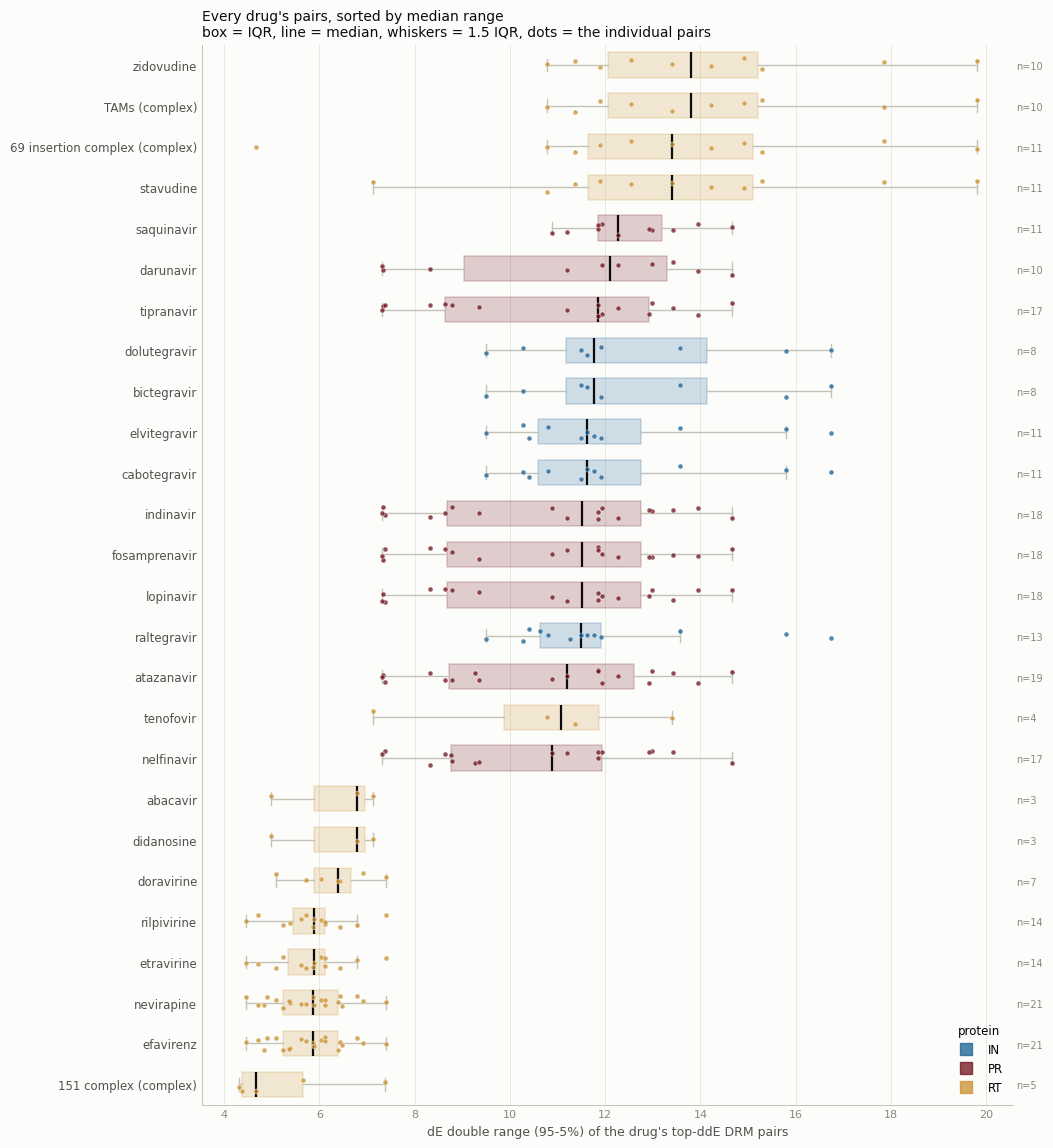

,protein,drug,pairs,median,iqr,min,max,span
25,RT,zidovudine,10,13.80,3.14,10.79,19.80,9.01
15,RT,TAMs,10,13.80,3.14,10.79,19.80,9.01
14,RT,69 insertion complex,11,13.40,3.47,4.67,19.80,15.13
23,RT,stavudine,11,13.40,3.47,7.13,19.80,12.67
11,PR,saquinavir,11,12.28,1.35,10.87,14.67,3.79
6,PR,darunavir,10,12.11,4.26,7.31,14.67,7.35
12,PR,tipranavir,17,11.84,4.28,7.31,14.67,7.35
0,IN,bictegravir,8,11.76,2.95,9.50,16.74,7.25
2,IN,dolutegravir,8,11.76,2.95,9.50,16.74,7.25
1,IN,cabotegravir,11,11.61,2.15,9.50,16.74,7.25


widest internal spread -- the drugs whose median says least about their pairs:
protein                 drug  pairs  median   min   max  span
     RT 69 insertion complex     11   13.40  4.67 19.80 15.13
     RT            stavudine     11   13.40  7.13 19.80 12.67
     RT           zidovudine     10   13.80 10.79 19.80  9.01
     RT                 TAMs     10   13.80 10.79 19.80  9.01
     PR            darunavir     10   12.11  7.31 14.67  7.35


In [11]:
COMPLEXES = {'TAMs', '69 insertion complex', '151 complex'}

order = DRUG.sort_values('median range')[['protein', 'drug']].to_numpy()
labels, data, colors = [], [], []
for P, d in order:
    v = DRUG_PAIRS[(DRUG_PAIRS['protein'] == P) & (DRUG_PAIRS['drug'] == d)]['range'].to_numpy()
    labels.append(f"{d} (complex)" if d in COMPLEXES else d)
    data.append(v)
    colors.append(PROT_COLOR[P])

fig, ax = plt.subplots(figsize=(10.6, 0.36 * len(data) + 2.2))
bare(ax, grid='x')

bp = ax.boxplot(data, vert=False, widths=.62, patch_artist=True, showfliers=False,
                medianprops=dict(color=INK, lw=1.6),
                whiskerprops=dict(color=BASE, lw=1), capprops=dict(color=BASE, lw=1))
for patch, c in zip(bp['boxes'], colors):
    patch.set(facecolor=c, alpha=.20, edgecolor=c, linewidth=1.1)

rng_jit = np.random.default_rng(0)
for k, (v, c) in enumerate(zip(data, colors), start=1):
    ax.scatter(v, k + rng_jit.uniform(-.17, .17, v.size), s=13, color=c, alpha=.75,
               edgecolor=SURFACE, linewidth=.4, zorder=3)
    ax.annotate(f"n={v.size}", (ax.get_xlim()[1], k), xytext=(2, -3),
                textcoords='offset points', fontsize=7, color=MUTED, annotation_clip=False)

ax.set_yticks(range(1, len(labels) + 1))
ax.set_yticklabels(labels, fontsize=8.5, color=INK2)
ax.set_xlabel('dE double range (95-5%) of the drug\'s top-ddE DRM pairs', fontsize=9, color=INK2)
ax.set_title('Every drug\'s pairs, sorted by median range\n'
             'box = IQR, line = median, whiskers = 1.5 IQR, dots = the individual pairs',
             fontsize=10, color=INK, loc='left')
ax.legend(handles=[plt.Line2D([], [], marker='s', ls='', color=PROT_COLOR[P], label=P,
                              markersize=8, alpha=.75) for P in PROTEINS],
          fontsize=8.5, loc='lower right', title='protein', title_fontsize=8.5)
fig.tight_layout()
fig.savefig(out_dir / 'de_range_by_drug_box.pdf', bbox_inches='tight')
fig.savefig(out_dir / 'de_range_by_drug_box.png', dpi=220, bbox_inches='tight')
plt.show()

SPREAD = (DRUG_PAIRS.groupby(['protein', 'drug'])['range']
          .agg(pairs='size', median='median', iqr=lambda v: v.quantile(.75) - v.quantile(.25),
               min='min', max='max')
          .reset_index().sort_values('median', ascending=False))
SPREAD['span'] = SPREAD['max'] - SPREAD['min']
display(SPREAD.round(2))
print("widest internal spread -- the drugs whose median says least about their pairs:")
print(SPREAD.nlargest(5, 'span')[['protein', 'drug', 'pairs', 'median', 'min', 'max', 'span']]
      .round(2).to_string(index=False))

## The same box plot, built from every DRM pair a drug has

The box plot above inherits a selection the drug never made: its pairs are the top 20 by ddE for the
whole protein, so a drug is scored on whichever of those 20 happen to touch one of its positions.
Two drugs can differ only because the top-20 list leaned toward one of them.

This section rebuilds it from the drug's own mutations instead:

1. take every DRM the drug has — **Stanford substitutions** (`drug_resistant_pair_*_stanford.tsv`,
   position / consensus / mutant) at the **IAS-USA positions** the drug lists, NRTI and NNRTI
   substitution tables kept apart for RT;
2. form **all pairwise combinations** of them at distinct positions;
3. map both substitutions into the reduced alphabet and drop any that collapse (consensus and
   mutant land on the same letter) or fall outside the modelled range;
4. **keep a pair only if its bivariate marginal in the MSA is non-zero** — at least one patient
   sequence carries both reduced mutant residues, so the pair is something the virus actually does;
5. take the 95–5 percentile ΔE double range exactly as before.

Two bookkeeping points. Several distinct substitutions collapse onto one reduced letter (Q148H/K/R,
the T215 family), so the pairs are de-duplicated *after* reduction and one reduced pair may stand
for several Stanford pairs. And a pair reachable from two drugs is drawn once in each drug's row
with the same value, as before.

In [12]:
import itertools

STANFORD = {
    'IN': [('IN/data/drug_resistant_pair_INSTI_stanford.tsv', 'INSTI')],
    'PR': [('PR/data/drug_resistant_pair_PI_stanford.tsv', 'PI')],
    'RT': [('RT/data/drug_resistant_pair_stanford_NRTI.tsv', 'NRTI'),
           ('RT/data/drug_resistant_pair_stanford_NNRTI.tsv', 'NNRTI')],
}
NNRTI_DRUGS = {'doravirine', 'efavirenz', 'etravirine', 'nevirapine', 'rilpivirine'}

DRM_LIST = {}
for P in PROTEINS:
    rows = []
    for fn, cls in STANFORD[P]:
        for r in csv.DictReader(open(data_root / fn, newline=''), delimiter='\t'):
            rows.append((int(r['Position']), r['Consensus'].strip(), r['DRM'].strip(), cls))
    DRM_LIST[P] = rows
    print(f"{P}: {len(rows)} Stanford DRM substitutions")


def reduced_mutation(P, sub):
    """'T66I' -> (0-based position, wt index, mt index), or None if it cannot be represented.

    None means one of three things, all of them real losses rather than errors: the position is
    outside the modelled range, the substitution is not in the reduction dictionary, or consensus
    and mutant fall in the same reduced class so the mutation is invisible to a 4-letter model.
    """
    cfg = CFG[P]
    try:
        wt, pos, mt = functions.split_pair(functions.unreduced_to_reduced(cfg['redux'], sub))
    except Exception:
        return None
    if '-' in (wt, mt) or wt == mt:
        return None
    if not (cfg['min_pos'] <= pos <= cfg['max_pos']):
        return None
    return (pos - cfg['min_pos'], "ABCD".index(wt), "ABCD".index(mt))


def de_double_idx(P, a, b):
    """dE double per sequence for two already-reduced mutations a=(p,wt,mt), b=(p,wt,mt)."""
    cfg = CFG[P]
    (p1, wt1, mt1), (p2, wt2, mt2) = a, b
    S1 = _site_energies(cfg['onehot'], cfg['Jm'], p1, (p1, p2))
    S2 = _site_energies(cfg['onehot'], cfg['Jm'], p2, (p1, p2))
    J12 = cfg['Jm'][p1, p2, :, :4].astype(np.float64)
    M = S1[:, :, None] + S2[:, None, :] + J12[None, :, :]
    return M[:, wt1, wt2] - M[:, mt1, mt2]


ALL_ROWS, AUDIT, _de_cache = [], [], {}
for P in PROTEINS:
    cfg = CFG[P]
    for drug, plist in DRUGS[P].items():
        want = ('NNRTI' if drug in NNRTI_DRUGS else 'NRTI') if P == 'RT' else None
        muts, dropped = [], 0
        for pos, wt_aa, mt_aa, cls in DRM_LIST[P]:
            if pos not in plist or (want is not None and cls != want):
                continue
            red = reduced_mutation(P, f"{wt_aa}{pos}{mt_aa}")
            if red is None:
                dropped += 1
                continue
            muts.append((f"{wt_aa}{pos}{mt_aa}", red))

        # all combinations at distinct positions, de-duplicated after reduction
        uniq = {}
        for (na, ra), (nb, rb) in itertools.combinations(muts, 2):
            if ra[0] == rb[0]:
                continue
            uniq.setdefault(tuple(sorted([ra, rb])), []).append(f"{na}-{nb}")

        kept = 0
        for (a, b), names in uniq.items():
            count = int(((cfg['codes'][:, a[0]] == a[2]) & (cfg['codes'][:, b[0]] == b[2])).sum())
            if count == 0:                      # bivariate marginal is zero -- never co-observed
                continue
            key = (P, a, b)
            if key not in _de_cache:
                de = de_double_idx(P, a, b)
                lo, hi = np.percentile(de, [5, 95])
                _de_cache[key] = (hi - lo, de.mean())
            rng_, mean_ = _de_cache[key]
            kept += 1
            ALL_ROWS.append({
                'protein': P, 'drug': drug,
                'pair': names[0], 'reduced pair': f"{cfg['positions'][a[0]]}-{cfg['positions'][b[0]]}",
                'stanford pairs on this reduced pair': len(names),
                'bivariate count': count, 'range': rng_, 'mean dE double': mean_})
        AUDIT.append({'protein': P, 'drug': drug, 'DRMs used': len(muts),
                      'DRMs dropped in reduction': dropped,
                      'reduced pairs': len(uniq), 'kept (count > 0)': kept})

ALLP = pd.DataFrame(ALL_ROWS)
AUDIT = pd.DataFrame(AUDIT)
print(f"\n{len(ALLP)} (drug, pair) rows   "
      f"{ALLP.groupby(['protein', 'reduced pair']).ngroups} distinct reduced position pairs   "
      f"vs {len(DRUG_PAIRS)} rows / {DRUG_PAIRS[['protein', 'pair']].drop_duplicates().shape[0]} "
      f"pairs in the top-20 version")
display(AUDIT)

IN: 51 Stanford DRM substitutions
PR: 58 Stanford DRM substitutions
RT: 108 Stanford DRM substitutions



2227 (drug, pair) rows   338 distinct reduced position pairs   vs 313 rows / 71 pairs in the top-20 version


,protein,drug,DRMs used,DRMs dropped in reduction,reduced pairs,kept (count > 0)
0,IN,bictegravir,13,2,38,16
1,IN,cabotegravir,19,5,110,35
2,IN,dolutegravir,15,4,59,23
3,IN,elvitegravir,22,4,142,35
4,IN,raltegravir,26,5,142,54
5,PR,atazanavir,44,3,286,251
6,PR,darunavir,16,3,52,49
7,PR,fosamprenavir,30,3,143,138
8,PR,indinavir,31,2,160,154
9,PR,lopinavir,36,3,242,233


### The plot

Same axes and same box semantics as before — x is the 95–5 percentile ΔE double range of one pair
over the whole alignment, a dot is one pair, the box is the IQR *across a drug's pairs* — but the
population of dots is now everything the drug's own DRMs can make and the MSA has actually seen
together, rather than the protein-wide top-20 ddE list.

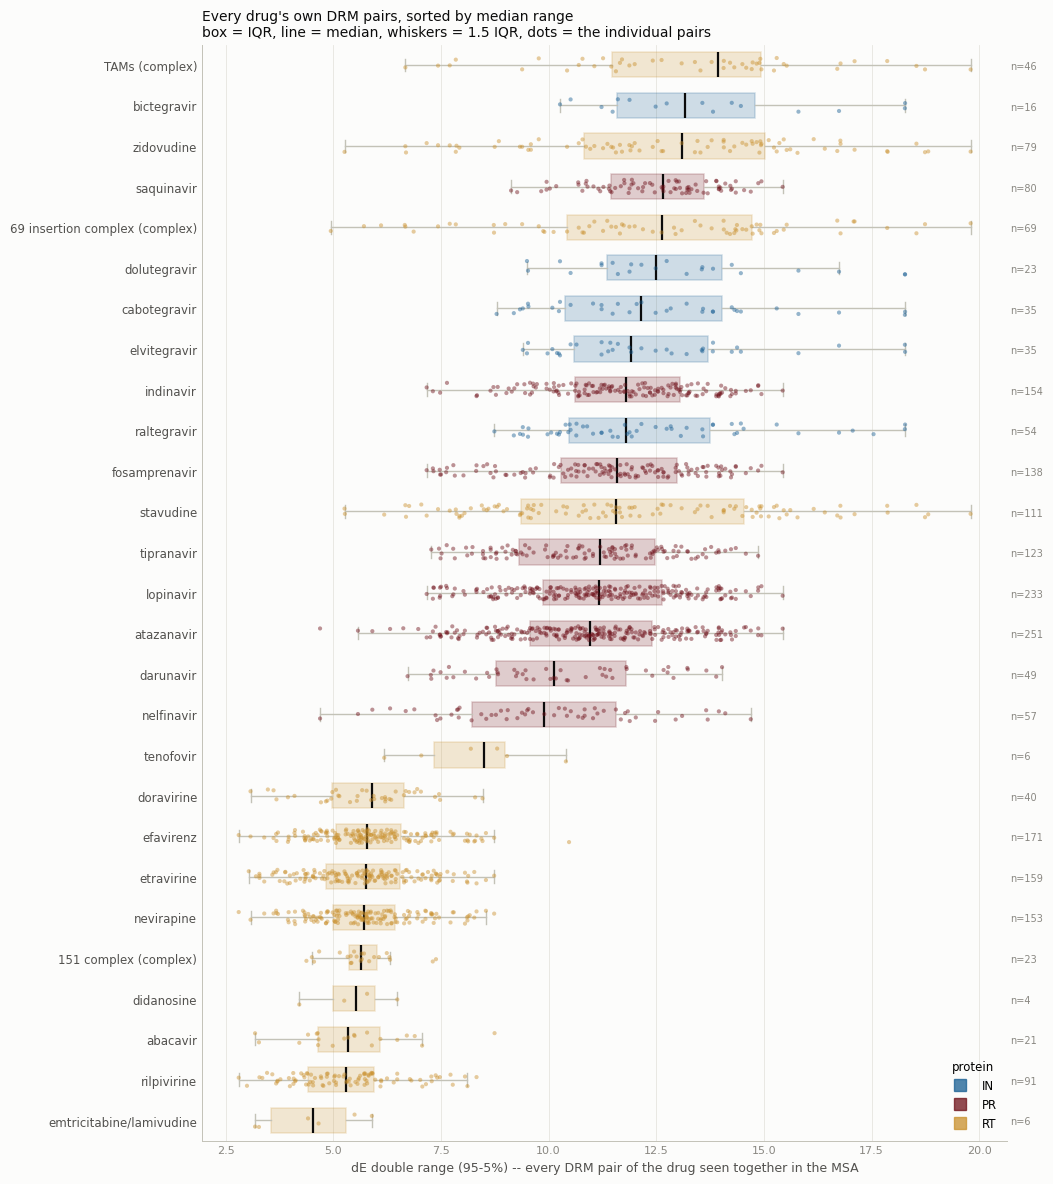

,protein,drug,pairs,median,iqr,min,max,median_bivariate_count
15,RT,TAMs,46,13.92,3.45,6.67,19.80,223.0
0,IN,bictegravir,16,13.16,3.22,10.26,18.28,8.0
26,RT,zidovudine,79,13.09,4.20,5.26,19.80,169.0
11,PR,saquinavir,80,12.67,2.16,9.13,15.43,43.5
14,RT,69 insertion complex,69,12.62,4.29,4.94,19.80,128.0
2,IN,dolutegravir,23,12.49,2.68,9.50,18.28,5.0
1,IN,cabotegravir,35,12.15,3.65,8.79,18.28,4.0
3,IN,elvitegravir,35,11.92,3.12,9.40,18.28,4.0
8,PR,indinavir,154,11.81,2.43,7.17,15.43,42.5
4,IN,raltegravir,54,11.80,3.29,8.74,18.28,4.0



per-drug median, top-20 construction vs all-DRM construction: Spearman rho = 0.851, p = 0.0000 (n = 26 drugs)
median absolute shift = 0.56 energy units


top20 median  all-DRM median  shift
protein drug                                                     
RT      tenofovir                    11.08            8.50  -2.58
PR      darunavir                    12.11           10.12  -1.99
RT      stavudine                    13.40           11.56  -1.83
        abacavir                      6.79            5.34  -1.44
        didanosine                    6.79            5.52  -1.27
PR      nelfinavir                   10.87            9.90  -0.97
RT      69 insertion complex         13.40           12.62  -0.77
        zidovudine                   13.80           13.09  -0.72
PR      tipranavir                   11.84           11.20  -0.64
RT      rilpivirine                   5.88            5.30  -0.58
        doravirine                    6.39            5.91  -0.48
PR      lopinavir                    11.52           11.18  -0.34
        atazanavir                   11.20           10.97  -0.23
RT      nevirapine                    5.87            5.71  -0.16
        etravirine                    5.88            5.77  -0.11
        efavirenz                     5.87            5.78  -0.08
PR      fosamprenavir                11.52           11.58   0.06
RT      TAMs                         13.80           13.92   0.12
PR      indinavir                    11.52           11.81   0.29
IN      elvitegravir                 11.61           11.92   0.31
        raltegravir                  11.49           11.80   0.31
PR      saquinavir                   12.28           12.67   0.39
IN      cabotegravir                 11.61           12.15   0.55
        dolutegravir                 11.76           12.49   0.72
RT      151 complex                   4.67            5.64   0.97
IN      bictegravir                  11.76           13.16   1.39


wrote de_range_all_drm_pairs_by_drug.csv and _audit.csv


In [13]:
MED = (ALLP.groupby(['protein', 'drug'])['range'].median().reset_index()
       .sort_values('range'))

labels, data, colors = [], [], []
for _, r in MED.iterrows():
    v = ALLP[(ALLP['protein'] == r['protein']) & (ALLP['drug'] == r['drug'])]['range'].to_numpy()
    labels.append(f"{r['drug']} (complex)" if r['drug'] in COMPLEXES else r['drug'])
    data.append(v)
    colors.append(PROT_COLOR[r['protein']])

fig, ax = plt.subplots(figsize=(10.6, 0.36 * len(data) + 2.2))
bare(ax, grid='x')

bp = ax.boxplot(data, vert=False, widths=.62, patch_artist=True, showfliers=False,
                medianprops=dict(color=INK, lw=1.6),
                whiskerprops=dict(color=BASE, lw=1), capprops=dict(color=BASE, lw=1))
for patch, c in zip(bp['boxes'], colors):
    patch.set(facecolor=c, alpha=.20, edgecolor=c, linewidth=1.1)

jit = np.random.default_rng(0)
for k, (v, c) in enumerate(zip(data, colors), start=1):
    ax.scatter(v, k + jit.uniform(-.17, .17, v.size), s=9, color=c, alpha=.45,
               edgecolor='none', zorder=3)
    ax.annotate(f"n={v.size}", (ax.get_xlim()[1], k), xytext=(2, -3),
                textcoords='offset points', fontsize=7, color=MUTED, annotation_clip=False)

ax.set_yticks(range(1, len(labels) + 1))
ax.set_yticklabels(labels, fontsize=8.5, color=INK2)
ax.set_xlabel("dE double range (95-5%) -- every DRM pair of the drug seen together in the MSA",
              fontsize=9, color=INK2)
ax.set_title("Every drug's own DRM pairs, sorted by median range\n"
             'box = IQR, line = median, whiskers = 1.5 IQR, dots = the individual pairs',
             fontsize=10, color=INK, loc='left')
ax.legend(handles=[plt.Line2D([], [], marker='s', ls='', color=PROT_COLOR[P], label=P,
                              markersize=8, alpha=.75) for P in PROTEINS],
          fontsize=8.5, loc='lower right', title='protein', title_fontsize=8.5)
fig.tight_layout()
fig.savefig(out_dir / 'de_range_by_drug_box_all_drm_pairs.pdf', bbox_inches='tight')
fig.savefig(out_dir / 'de_range_by_drug_box_all_drm_pairs.png', dpi=220, bbox_inches='tight')
plt.show()

SUMM = (ALLP.groupby(['protein', 'drug'])
        .agg(pairs=('range', 'size'), median=('range', 'median'),
             iqr=('range', lambda v: v.quantile(.75) - v.quantile(.25)),
             min=('range', 'min'), max=('range', 'max'),
             median_bivariate_count=('bivariate count', 'median'))
        .reset_index().sort_values('median', ascending=False))
display(SUMM.round(2))

# does the rebuild agree with the top-20 version?
OLD = DRUG_PAIRS.groupby(['protein', 'drug'])['range'].median().rename('top20 median')
NEW = ALLP.groupby(['protein', 'drug'])['range'].median().rename('all-DRM median')
CMP = pd.concat([OLD, NEW], axis=1).dropna()
r_, p_, n_ = rho(CMP['top20 median'], CMP['all-DRM median'])
print(f"\nper-drug median, top-20 construction vs all-DRM construction: "
      f"Spearman rho = {r_:.3f}, p = {p_:.4f} (n = {n_} drugs)")
print(f"median absolute shift = {(CMP['all-DRM median'] - CMP['top20 median']).abs().median():.2f} "
      f"energy units")
display(CMP.assign(shift=CMP['all-DRM median'] - CMP['top20 median'])
        .sort_values('shift').round(2))

ALLP.to_csv(out_dir / 'de_range_all_drm_pairs_by_drug.csv', index=False)
AUDIT.to_csv(out_dir / 'de_range_all_drm_pairs_audit.csv', index=False)
print('\nwrote de_range_all_drm_pairs_by_drug.csv and _audit.csv')

## What the data supports, and what it does not

**Supported.**

1. **ΔE double decides who carries the pair — at every range.** All 80 pairs separate carriers from
   non-carriers with AUC 0.67–1.00 (median 0.93), computed from background positions only, disjoint
   from the residues the carrier flag reads. The background is not a nuisance term; it is most of
   what decides which sequences hold a resistance pair.
2. **A wide range is a concentrated range.** Wide pairs lean on one or two background positions
   (N_eff ≈ 2–5); narrow ones spread the same job over ten to twenty (N_eff ≈ 10–20). RT ρ = −0.58,
   p = 0.0002; PR ρ = −0.44, p = 0.05.
3. **For the widest pairs the dominant position is a named partner DRM** — 41 for L210W-T215Y (51%
   of the spread), 210 for M41L-T215Y (41%), 140 for the IN Q148H pairs (65%), 82 and 10 for the PR
   pairs. A wide range means: this pair is cheap in a background that already carries its partner
   mutation and expensive in one that does not.
4. So the reading of a wide ΔE double range is **an energy scale, not a gate**: how many kT separate
   a good background from a bad one for this pair. Which is also why it does not translate into a
   clinical timeline on its own.

**Contradicted by the data — my own drafts of these were wrong before running them.**

* **A wide range does not mean stronger background gating.** The carrier-enrichment curve is
  identical across range tertiles: about 75% of a pair's carriers sit in the top decile of
  background for narrow, middle and wide alike. Scored against the ceiling each pair could attain,
  enrichment against range is flat everywhere (pooled ρ = 0.13, RT −0.24, both ns). Relative gating is a constant of
  these pairs; only the energy scale varies.
* **Wide pairs being the common ones is mostly a mean effect, not a range effect.** Inside RT the
  raw ρ = 0.63 falls to a partial ρ = 0.17 once mean ΔE double is held fixed.
* **Leaning on resistance positions is not what makes a range wide.** Every pair's spread is
  dominated by DRM positions (median 0.80 of it on 0.16 of positions in RT); the correlation with
  range is null except in PR.

**Out of reach here.**

* The IN pairs span 9.5–16.7 and nothing tests inside that; every IN correlation above is
  consistent with noise. Read RT first, then PR.
* `frac favoured` is near-mechanical given the mean and sd — a restatement of the range.
* None of this says a wide range makes resistance appear sooner. It says a pair's energetics are
  set by a short list of companion positions rather than the bulk background. Whether a gate that
  one specific partner mutation opens is crossed faster or slower in a patient depends on mutational
  supply and drug pressure, which these couplings do not contain — which is the honest reason the
  drug-level scatter in `de_range_vs_resistance_time_v1.ipynb` was weak.